# Are Yu-Gi-Oh! cards sharing same type more likely to interact with each other ?

**Author**: Farès Blibeche

**Date**: April, 2026

# 0. Problem

The famous Japanese card game Yu-Gi-Oh is known for its complex combinations, creative decks and diversity of cards, types, effects... Understanding the underlying rules behind deck building is one of the most important aspect of the game.
Choosing the right card is usually based on experience and knowledge of existant cards.

This study aims to answer the following question by exploiting numerical methods:

**Are cards sharing same type more likely to interact with each other?"**

In a last studies, we tried to detect interactions by identifying pieces of text that indicate another card name, frame type etc.

This time, we'll use a dataset of card interactions build by an LLM prompted with domain-specific instructions. Unlike rule-based methods, this approach allows us to capture semantic interactions beyond explicit text matching.

# 1. Settings

## 1.1 Libraries importation

In [46]:
# import sys
# !{sys.executable} -m pip install pandas matplotlib seaborn 

In [47]:
import os
import math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
plt.rcdefaults()
plt.rcParams["figure.dpi"] = 220
plt.style.use('Styles/style_report.mplstyle')

## 1.2 Paths

In [48]:
ALLCARDS_PATH = Path("C:/Users/fares/Desktop/RENDU/Data/all_ygo_cards.csv")
INTERACTIONS_PATH = Path("C:/Users/fares/Desktop/RENDU/Interactions/interactions.csv")
MODELS_PATH = Path("Models")

# 2. Data import

In [49]:
dfCards = pd.read_csv(ALLCARDS_PATH)
display(dfCards)

,id,name,desc,atk,defe,attribute,type,frametype,level,card_sets
0,80181649,"""A Case for K9""","When this card is activated: You can add 1 ""K9...",NaN,NaN,NaN,Continuous,spell,NaN,Justice Hunters | Justice Hunters
1,34541863,"""A"" Cell Breeding Device","During each of your Standby Phases, put 1 A-Co...",NaN,NaN,NaN,Continuous,spell,NaN,Force of the Breaker
2,64163367,"""A"" Cell Incubator",Each time an A-Counter(s) is removed from play...,NaN,NaN,NaN,Continuous,spell,NaN,Gladiator's Assault
3,91231901,"""A"" Cell Recombination Device",Target 1 face-up monster on the field; send 1 ...,NaN,NaN,NaN,Quick-Play,spell,NaN,Invasion: Vengeance
4,73262676,"""A"" Cell Scatter Burst","Select 1 face-up ""Alien"" monster you control. ...",NaN,NaN,NaN,Quick-Play,spell,NaN,Strike of Neos
...,...,...,...,...,...,...,...,...,...,...
14132,2648201,ZW - Sleipnir Mail,"You can target 1 ""Utopia"" monster you control;...",1000.0,1000.0,LIGHT,Beast,effect,4.0,Primal Origin
14133,95886782,ZW - Sylphid Wing,"You can only control 1 ""ZW - Sylphid Wing"". Yo...",800.0,1600.0,LIGHT,Beast,effect,4.0,Brothers of Legend
14134,81471108,ZW - Tornado Bringer,"You can target 1 ""Utopia"" monster you control;...",1300.0,1800.0,WIND,Dragon,effect,5.0,Cosmo Blazer | King's Court
14135,18865703,ZW - Ultimate Shield,When this card is Normal or Special Summoned: ...,0.0,2000.0,EARTH,Aqua,effect,4.0,Cosmo Blazer | King's Court


In [50]:
dfInteractions = pd.read_csv(INTERACTIONS_PATH)
display(dfInteractions)

,id_cardA,id_cardB,destroy,references_type,mill_from_deck,mentions_name,equip,mentions_archetype,link_summon,reduce_atk,...,references_atk,set_from_deck,change_level,buff_def,skip_phase,references_level,reduce_def,cannot_be_destroyed,buff_atk,synchro_summon
0,47297616,78792195,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57285770,49154689,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,26902560,11471117,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,80316585,12923641,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,55343172,40975574,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27412,96795312,77864539,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27413,81275309,43332022,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27414,84766279,27944249,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27415,30213599,34487429,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 3. Feature engineering

### 3.1 Build dfFeatures

In [51]:
# ── Interaction columns ──────────────────────────────────────────────────
interaction_cols = [
    col for col in dfInteractions.columns
    if col not in ['id_cardA', 'id_cardB']
]

# ── id_pair ──────────────────────────────────────────────────────────────
dfInteractions["id_pair"] =  dfInteractions["id_cardA"].astype(str) + "-" + dfInteractions["id_cardB"].astype(str)

# ── interactCount : mean number of active interactions per pair ───────────
interactCount = (
    dfInteractions.assign(n_ones=dfInteractions[interaction_cols].sum(axis=1))
    .groupby('id_pair')['n_ones']
    .mean()
    .rename('interactCount')
)

# ── repeatCount : number of times each pair was annotated ────────────────
repeatCount = dfInteractions['id_pair'].value_counts().rename('repeatCount')

# ── stability ────────────────────────────────────────────────────────────
# For pairs annotated more than once, check whether the LLM returned
# identical labels across all occurrences.
#   1  = all annotations agree
#   0  = at least one disagreement
#  -1  = pair appears only once (no comparison possible)

def is_pair_stable(subset):
    first_row = subset[interaction_cols].iloc[0]
    return int(subset[interaction_cols].eq(first_row).all(axis=1).all())

repeated_pairs = repeatCount[repeatCount > 1].index
stability = (
    dfInteractions[dfInteractions['id_pair'].isin(repeated_pairs)]
    .groupby('id_pair')
    .apply(is_pair_stable, include_groups=False)
    .rename('stability')
)

# ── dfFeatures ───────────────────────────────────────────────────────────
dfFeatures = (
    interactCount.to_frame()
    .join(repeatCount)
    .join(stability)
)
dfFeatures['stability'] = dfFeatures['stability'].fillna(1).astype(int)

dfFeatures[['id_cardA', 'id_cardB']] = (
    dfFeatures.index.to_series()
    .str.split('-', n=1, expand=True)
    .astype(int)
    .values
)

# ── Card properties ──────────────────────────────────────────────────────
card_cols = ['id', 'type', 'attribute', 'frametype', 'level', 'atk', 'defe']

dfFeatures = (
    dfFeatures
    .merge(dfCards[card_cols], left_on='id_cardA', right_on='id', how='left')
    .rename(columns={'type': 'type_A', 'attribute': 'attribute_A',
                     'frametype': 'frametype_A', 'level': 'level_A',
                     'atk': 'atk_A', 'defe': 'defe_A'})
    .drop(columns=['id'])
    .merge(dfCards[card_cols], left_on='id_cardB', right_on='id', how='left')
    .rename(columns={'type': 'type_B', 'attribute': 'attribute_B',
                     'frametype': 'frametype_B', 'level': 'level_B',
                     'atk': 'atk_B', 'defe': 'defe_B'})
    .drop(columns=['id'])
)

# Binary features
dfFeatures['sharedType']      = (dfFeatures['type_A']      == dfFeatures['type_B']).astype(int)
dfFeatures['sharedAttribute'] = (dfFeatures['attribute_A'] == dfFeatures['attribute_B']).astype(int)
dfFeatures['sharedFrametype'] = (dfFeatures['frametype_A'] == dfFeatures['frametype_B']).astype(int)
dfFeatures['repeated']        = (dfFeatures['repeatCount']  > 1).astype(int)
# Continuous features (absolute differences)
dfFeatures['lvDiff']   = (dfFeatures['level_A'] - dfFeatures['level_B']).abs()
dfFeatures['atkDiff']  = (dfFeatures['atk_A']   - dfFeatures['atk_B']).abs()
dfFeatures['defDiff']  = (dfFeatures['defe_A']  - dfFeatures['defe_B']).abs()

# Keep only relevant features 
feature_cols = ['interactCount', 'repeatCount', 'repeated', 'stability',
                'sharedType', 'sharedAttribute', 'sharedFrametype',
                'lvDiff', 'atkDiff', 'defDiff']

dfFeatures = dfFeatures[feature_cols]

# ── Display ──────────────────────────────────────────────────────
display(dfFeatures)


,interactCount,repeatCount,repeated,stability,sharedType,sharedAttribute,sharedFrametype,lvDiff,atkDiff,defDiff
0,0.0,1,0,1,0,0,0,NaN,NaN,NaN
1,1.0,1,0,1,0,0,0,NaN,NaN,NaN
2,1.0,1,0,1,0,0,0,3.0,1500.0,1900.0
3,0.0,1,0,1,0,0,0,6.0,2500.0,3200.0
4,0.0,1,0,1,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
24609,0.0,1,0,1,0,0,0,NaN,NaN,NaN
24610,0.0,1,0,1,0,0,0,NaN,NaN,NaN
24611,0.0,1,0,1,0,0,0,NaN,NaN,NaN
24612,0.0,1,0,1,0,0,0,NaN,NaN,NaN


In [52]:
#Count how much NaN in each column
dfFeatures.isna().sum()

interactCount          0
repeatCount            0
repeated               0
stability              0
sharedType             0
sharedAttribute        0
sharedFrametype        0
lvDiff             14872
atkDiff            14318
defDiff            15094
dtype: int64

### 3.2 Standardisation

In [53]:
dfFeatures = dfFeatures.dropna()

scaler = StandardScaler()
for col in ['lvDiff', 'atkDiff', 'defDiff', 'repeatCount']:
    dfFeatures[col] = scaler.fit_transform(dfFeatures[[col]])

print(f'dfFeatures : {dfFeatures.shape[0]} observations')

dfFeatures : 9518 observations


# 4. Data visualisation

In [54]:
def plot_variable(dataframe, variable, v_name="", title="", filename=False, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))

    sns.countplot(x=variable, data=dataframe, order=[0, 1], ax=ax)

    counts = dataframe[variable].value_counts()
    count0 = int(counts.iloc[counts.index == 0].sum()) if 0 in counts.index else 0
    count1 = int(counts.iloc[counts.index == 1].sum()) if 1 in counts.index else 0

    ax.text(0, count0, str(count0), ha='center', va='bottom')
    ax.text(1, count1, str(count1), ha='center', va='bottom')

    ax.set_xlabel(v_name)
    ax.set_ylabel("Number of couples")
    ax.set_title(title)

    if standalone and isinstance(filename, str):
        path = f'Latex/Figures/{filename}.png'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.savefig(path, dpi=300, bbox_inches='tight', transparent=True)


def figure_variables(dataframe, filename=False, saveIndividual=False, show=False):
    cols = dataframe.columns

    if saveIndividual:
        for col in cols:
            plot_variable(
                dataframe, str(col),
                v_name="value", title=col,
                filename=f'interactions_variables/{col}'
            )
            plt.close()

    # 2) Combined grid
    n_rows = math.ceil(len(cols) / 3)
    fig = plt.figure(figsize=(18, 5 * n_rows))
    plt.subplots_adjust(hspace=0.5)
    for i, col in enumerate(cols):
        ax = plt.subplot(n_rows, 3, i + 1)
        plot_variable(dataframe, str(col),
                      v_name="value", title=col, ax=ax)
    plt.tight_layout()

    if isinstance(filename, str):
        path = f'Latex/Figures/{filename}.png'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.savefig(path, dpi=300, bbox_inches='tight', transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

In [55]:
figure_variables(dfInteractions[interaction_cols], filename="interactions_variables", saveIndividual=True)

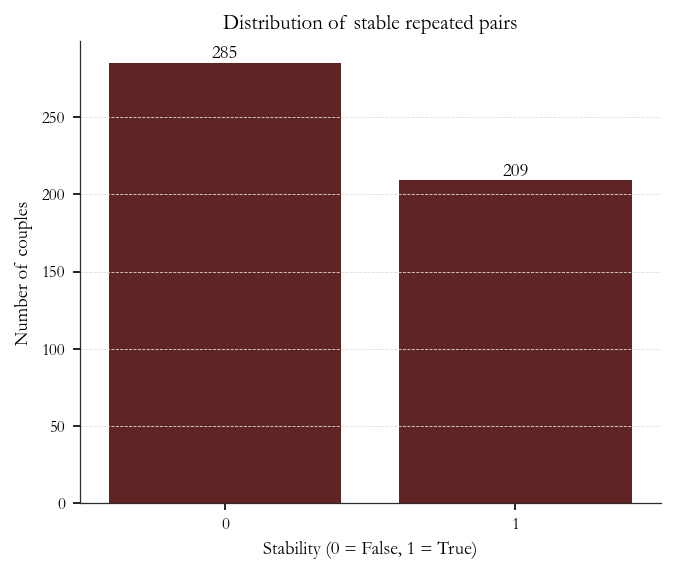

In [56]:
plot_variable(dfFeatures[dfFeatures['repeated'] == 1], "stability", v_name="Stability (0 = False, 1 = True)", title="Distribution of stable repeated pairs", filename="distribution_stability")

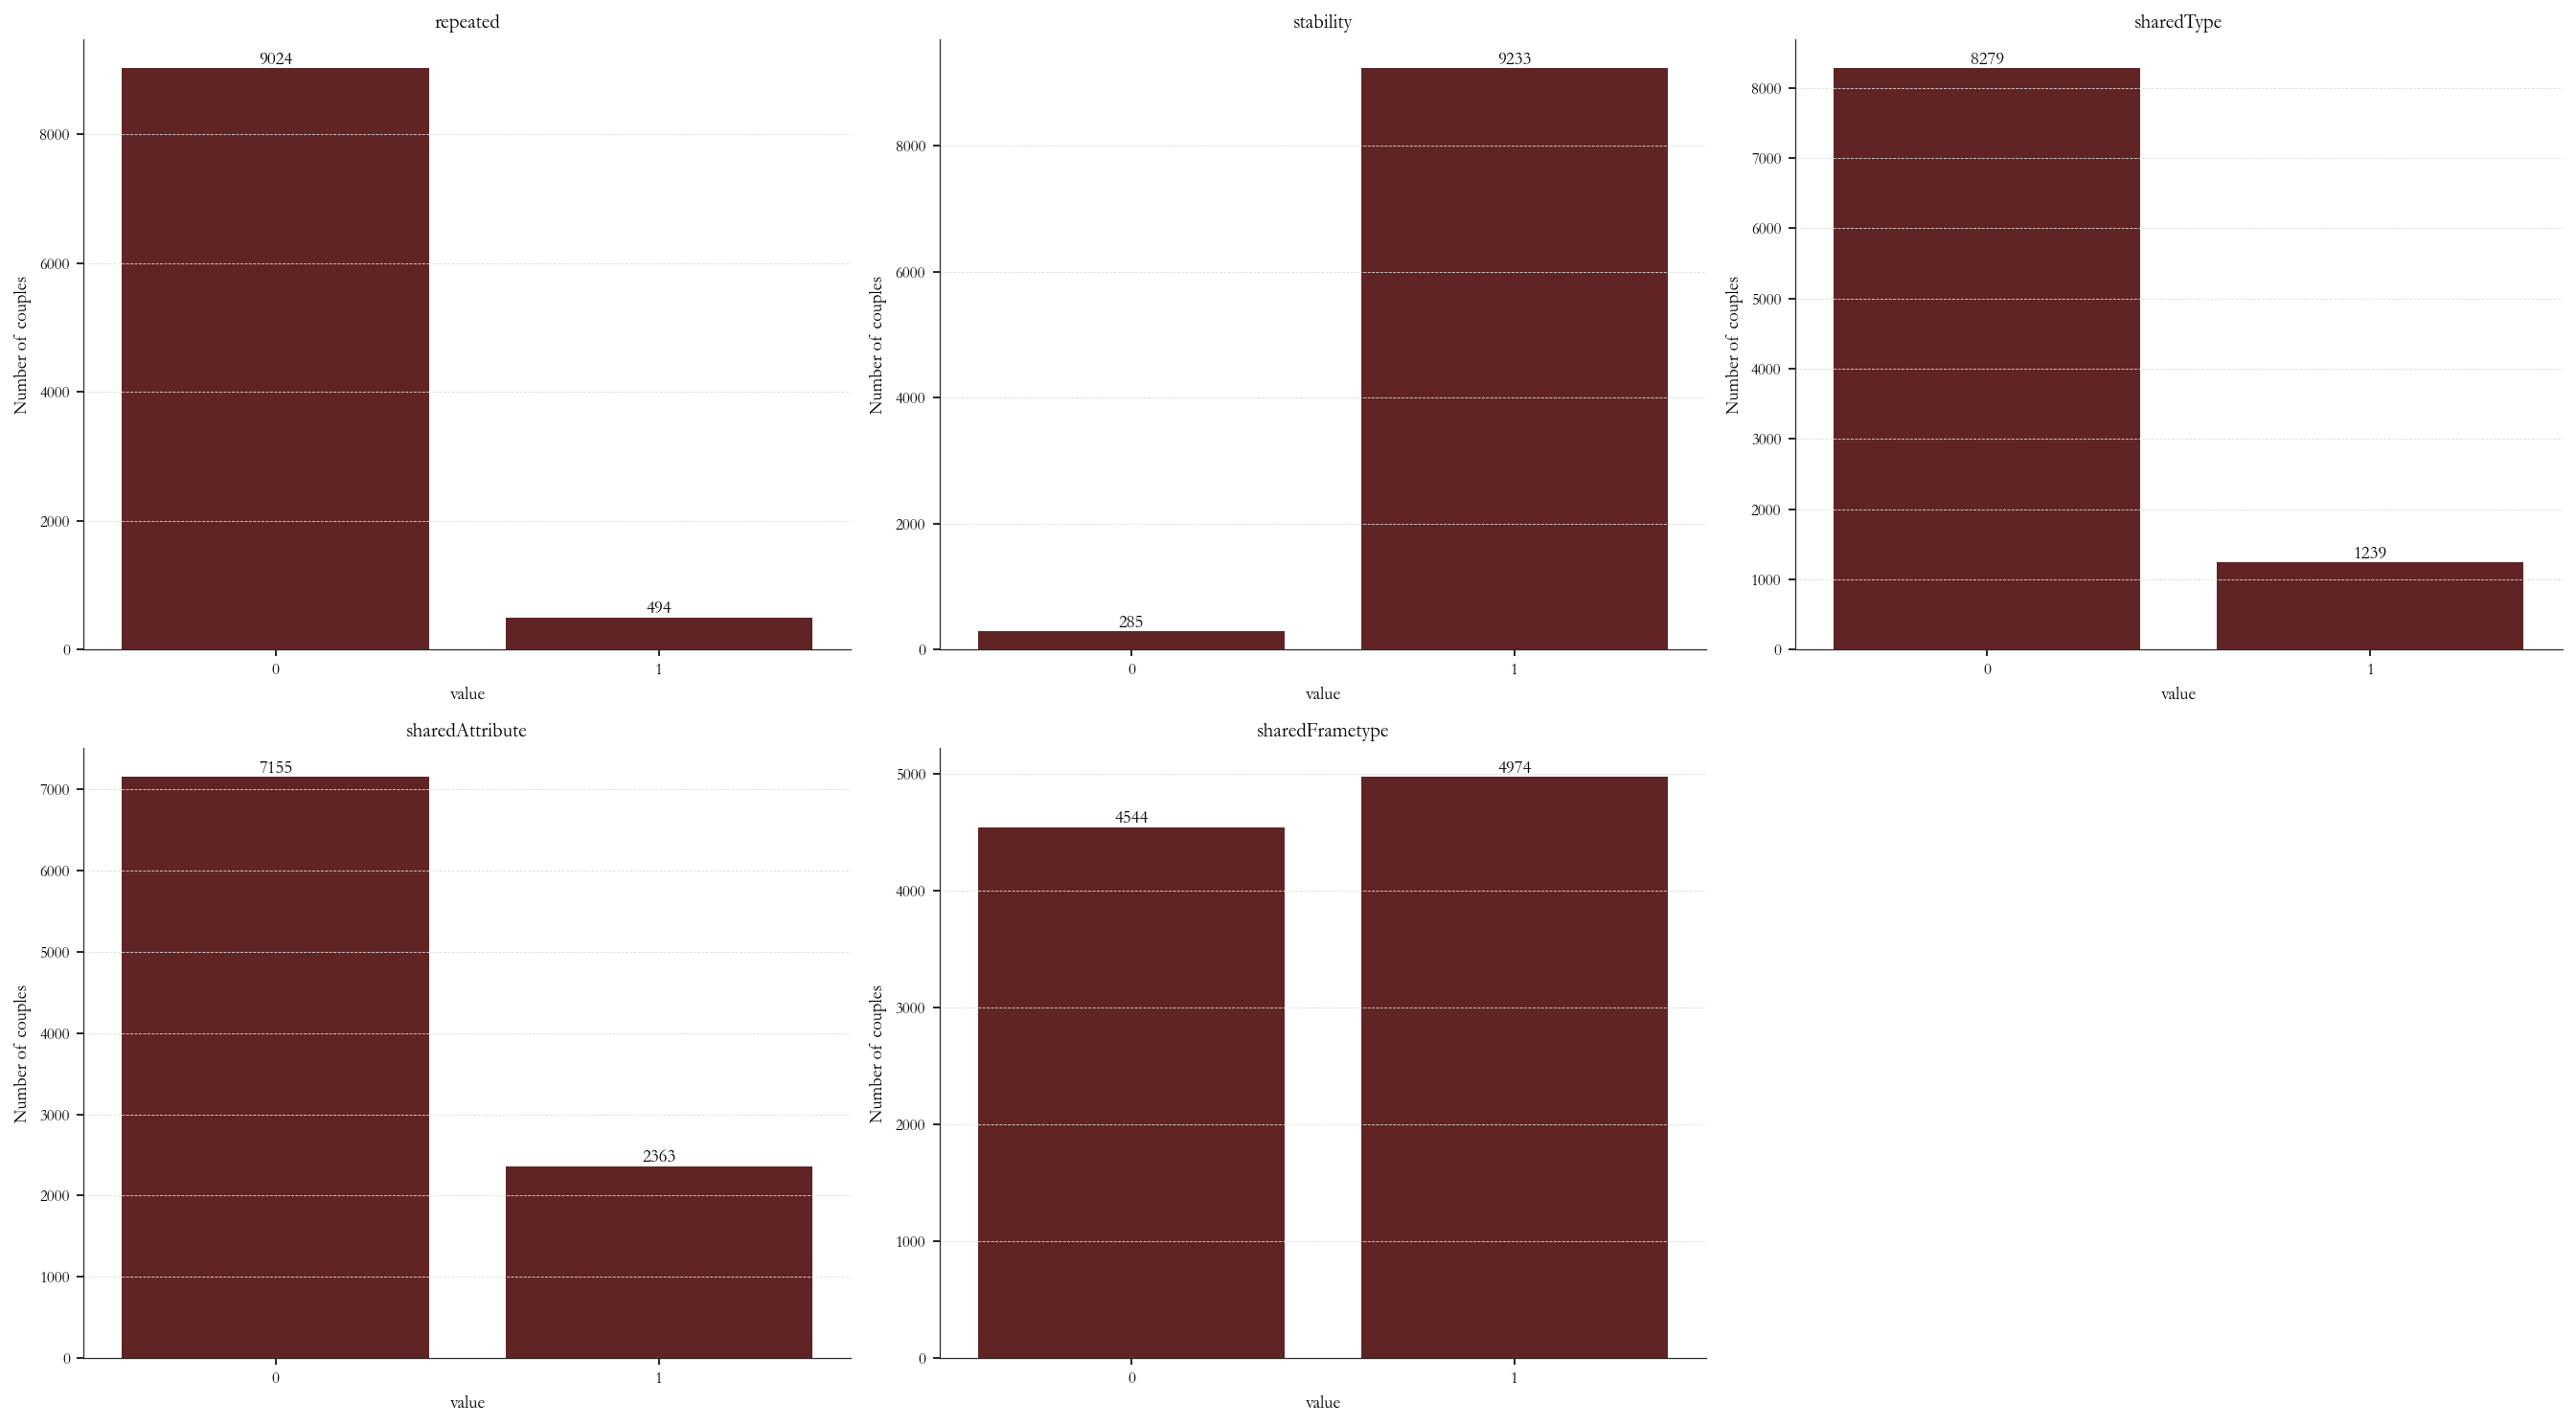

In [57]:
figure_variables(dfFeatures[['repeated', 'stability','sharedType', 'sharedAttribute', 'sharedFrametype']], filename="features_binary_values", show=True)

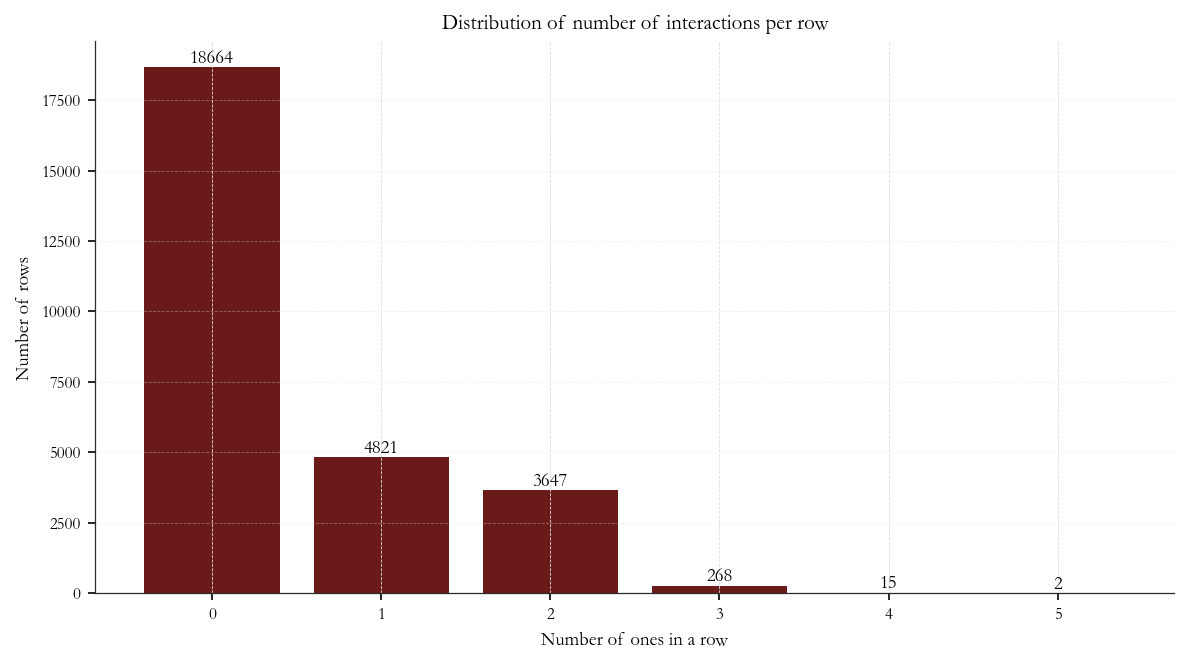

In [58]:
n_ones = dfInteractions[interaction_cols].sum(axis=1)
counts = n_ones.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(counts.index, counts.values, width=0.8)

ax.set_xlabel("Number of ones in a row")
ax.set_ylabel("Number of rows")
ax.set_title("Distribution of number of interactions per row")

ax.set_xticks(counts.index)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for x, y in zip(counts.index, counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(f'Latex/Figures/distribution_interactions.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### 3.3 Build X and Y

In [59]:
X = dfFeatures[['repeatCount','repeated','stability','sharedType','sharedAttribute','sharedFrametype','lvDiff','atkDiff','defDiff']].astype('float32')
Y = dfFeatures['interactCount']

In [60]:
X

,repeatCount,repeated,stability,sharedType,sharedAttribute,sharedFrametype,lvDiff,atkDiff,defDiff
2,-0.141223,0.0,1.0,0.0,0.0,0.0,0.213162,0.543732,1.240849
3,-0.141223,0.0,1.0,0.0,0.0,0.0,1.609499,1.773370,2.970967
6,-0.141223,0.0,1.0,0.0,0.0,1.0,3.005837,3.494863,3.902569
7,-0.141223,0.0,1.0,0.0,0.0,0.0,0.678608,1.158551,2.039365
8,0.696262,1.0,1.0,0.0,0.0,0.0,-0.252284,-0.071087,0.708505
...,...,...,...,...,...,...,...,...,...
24589,-0.141223,0.0,1.0,0.0,1.0,1.0,-1.183175,-0.071087,0.176161
24590,-0.141223,0.0,1.0,1.0,1.0,1.0,0.213162,-1.054797,1.507021
24591,-0.141223,0.0,1.0,0.0,0.0,1.0,0.678608,-0.439978,1.373935
24598,-0.141223,0.0,1.0,0.0,1.0,1.0,0.678608,1.035587,-0.888526


## 5. Data modelling

We compute the following multivariate linear model on monster pairs only:

$$\begin{aligned}
interactCount_i = \, & \alpha_1 \cdot \text{SameType}_i + \alpha_2 \cdot \text{SameAttr}_i + \alpha_3 \cdot \text{SameFrame}_i \\
                   + \, & \alpha_4 \cdot \text{LvDiff}_i + \alpha_5 \cdot \text{AtkDiff}_i + \alpha_6 \cdot \text{DefDiff}_i \\
                   + \, & \beta_1 \cdot \text{Stable}_i + \beta_2 \cdot \text{RepeatN}_i + \beta_3 \cdot \text{IsRepeat}_i +  \epsilon_i
\end{aligned}$$

Variables of interest: **SameType**, **SameAttr**, **SameFrame** capture whether the two cards share the same type, attribute, and frametype. **LvDiff**, **AtkDiff**, **DefDiff** control for combat stat similarity. **Stable**, **RepeatN** and **IsRepeat** are annotation-quality controls — a significant effect of these would indicate LLM inconsistency and would weaken confidence in the main coefficients.

### 5.1 Multivariate Linear Model

In [61]:
def regression(Yname, Xlist, dataframe, printSummary=True):
    model = smf.ols(
        formula=Yname + ' ~ ' + ' + '.join(Xlist),
        data=dataframe
    ).fit()
    if printSummary:
        print(model.summary())
    return model

predictors = ['repeatCount', 'repeated', 'stability', 'sharedType',
              'sharedAttribute', 'sharedFrametype', 'lvDiff', 'atkDiff', 'defDiff']

model = regression('interactCount', predictors, dfFeatures, printSummary=True)

                            OLS Regression Results                            
Dep. Variable:          interactCount   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     25.80
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           2.09e-44
Time:                        15:20:17   Log-Likelihood:                -10982.
No. Observations:                9518   AIC:                         2.198e+04
Df Residuals:                    9508   BIC:                         2.206e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.1786      0.073     

### 5.2 Forest Plot

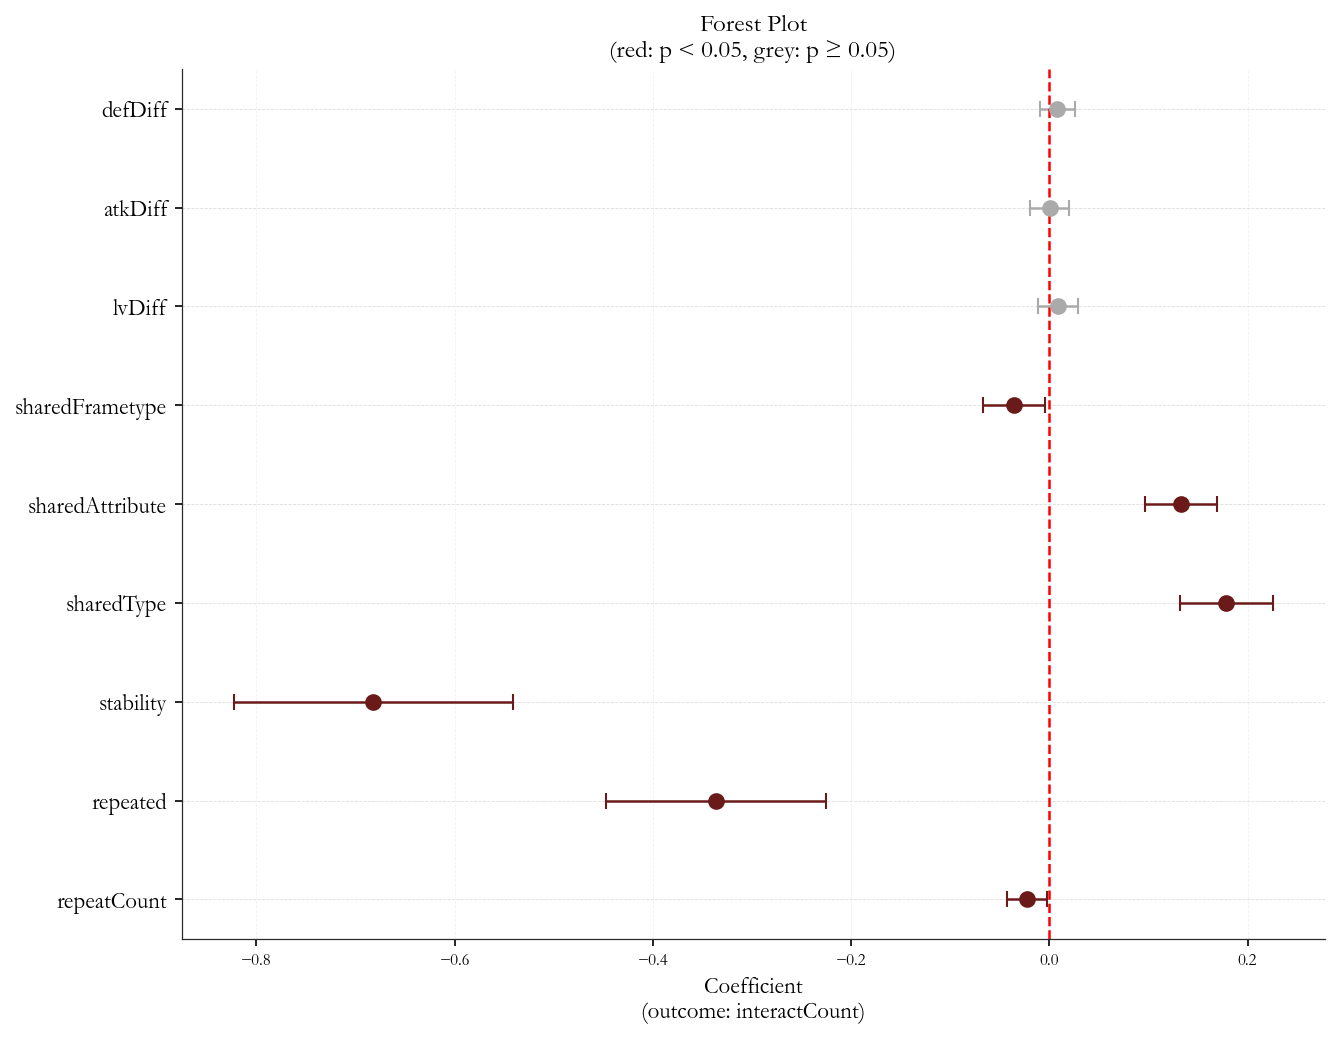

In [62]:
coefs  = model.params[1:]
ci     = (model.conf_int(alpha=0.05)[1] - model.conf_int(alpha=0.05)[0]) / 2
ci     = ci[1:]
y_pos  = range(1, len(predictors) + 1)
colors = ['#6B1A1A' if p < 0.05 else '#AAAAAA' for p in model.pvalues[1:]]

plt.figure(figsize=(9, 7))
for i, (coef, err, color) in enumerate(zip(coefs, ci, colors), start=1):
    plt.errorbar(coef, i, xerr=err, fmt='o', color=color, capsize=4, markersize=7)
plt.yticks(y_pos, predictors, fontsize=11)
plt.axvline(x=0, linestyle='--', color='red', linewidth=1.2)
plt.xlabel('Coefficient\n(outcome: interactCount)', fontsize=11)
plt.title('Forest Plot\n(red: p < 0.05, grey: p ≥ 0.05)', fontsize=12)
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(f'Latex/Figures/forest_plot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()